# Overview

### Middleware provides a way to more tightly control what happens inside the agent.
### Middleware is useful for the following:
* Tracking agent behavior with logging, analytics, and debugging.
* Transforming prompts, tool selection, and output formatting.
* Adding retries, fallbacks, and early termination logic.
* Applying rate limits, guardrails, and PII detection.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware, HumanInTheLoopMiddleware

agent = create_agent(
    model="gpt-5.5",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)

# Prebuilt middleware

| Middleware            	| Description                                                                                   	|
|-----------------------	|-----------------------------------------------------------------------------------------------	|
| Summarization         	| Automatically summarize conversation history when approaching token limits.                   	|
| Human-in-the-loop     	| Pause execution for human approval of tool calls.                                             	|
| Model call limit      	| Limit the number of model calls to prevent excessive costs.                                   	|
| Tool call limit       	| Control tool execution by limiting call counts.                                               	|
| Model fallback        	| Automatically fallback to alternative models when primary fails.                              	|
| PII detection         	| Detect and handle Personally Identifiable Information (PII).                                  	|
| To-do list            	| Equip agents with task planning and tracking capabilities.                                    	|
| LLM tool selector     	| Use an LLM to select relevant tools before calling main model.                                	|
| Tool error            	| Catch tool execution exceptions and convert them to error messages for the model.             	|
| Tool retry            	| Automatically retry failed tool calls with exponential backoff.                               	|
| Model retry           	| Automatically retry failed model calls with exponential backoff.                              	|
| LLM tool emulator     	| Emulate tool execution using an LLM for testing purposes.                                     	|
| Context editing       	| Manage conversation context by trimming or clearing tool uses.                                	|
| Provider tool search  	| Defer tools behind providers’ server-side tool search, surfacing them on demand.              	|
| Shell tool            	| Expose a persistent shell session to agents for command execution.                            	|
| File search           	| Provide Glob and Grep search tools over filesystem files.                                     	|
| Filesystem            	| Provide agents with a filesystem for storing context and long-term memories.                  	|
| Subagent              	| Add the ability to spawn subagents.                                                           	|
| Rubric grading (Beta) 	| Apply LLM-as-a-judge grading so agents self-evaluate and iterate until a rubric is satisfied. 	|

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [4]:
from langchain.chat_models import init_chat_model

model = init_chat_model('groq:llama-3.1-8b-instant')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


In [5]:
from langchain_core.tools import tool
import sqlite3

In [6]:
@tool
def save_trip_demo(user_id: str, destination: str) -> str:
    """Save a trip to the database. Irreversible without manual cleanup."""
    return f"Trip to {destination} saved for {user_id}."  # standing in for a real DB write

In [14]:
from langchain.agents import create_agent

from langchain.agents.middleware import SummarizationMiddleware


agent = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[save_trip_demo],
    middleware=[
        SummarizationMiddleware(
            model = 'gpt-oss-20b',
            trigger = ('tokens',1000),
            keep =('messages',10),
        )
    ])

#### Summarization is text-oriented context compression. It does not resize, downsample, or otherwise compress image/audio/video payloads. Recent messages retained by keep still include their original multimodal blocks, while older multimodal messages that are summarized are represented only by the generated text summary. For image-heavy applications, store media in a filesystem or object store and pass URLs or file references through message histor

In [15]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

In [18]:
config = {'configurable':{"thread_id":"hitl"}}

result =agent.invoke({"messages": [("user", "Send an email to my manager on vivek35ai@gmail.com, asking for a leave")]}, config=config)

In [19]:
result

{'messages': [HumanMessage(content='Send an email to my manager on mayank953ai@gmail.com, asking for a leave', additional_kwargs={}, response_metadata={}, id='3410f4d1-6dde-436f-92e3-82c374e15995'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bjmkm990b', 'function': {'arguments': '{"body":"Hi Manager, I am writing to request a leave.","recipient":"mayank953ai@gmail.com","subject":"Leave Request"}', 'name': 'your_send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 313, 'total_tokens': 357, 'completion_time': 0.049498516, 'completion_tokens_details': None, 'prompt_time': 0.025379111, 'prompt_tokens_details': None, 'queue_time': 0.051409642, 'total_time': 0.074877627}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe17e-7d34-7e32-910e-9e3e4342d9ed-0', t

```
User
  │
  │ "Send an email asking for leave"
  ▼
LLM
  │
  │ decides to call
  ▼
your_send_email_tool
  │
  │ requires approval
  ▼
INTERRUPT
  │
  ├── approve → send email
  ├── edit    → modify tool arguments
  └── reject  → don't send
```

In [20]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime

In [21]:
# --- LangGraph (checkpointing, resuming) ---
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

In [22]:
from langchain.agents.middleware import (
    SummarizationMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    TodoListMiddleware,
    LLMToolSelectorMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    LLMToolEmulator,
    ContextEditingMiddleware,
    ClearToolUsesEdit,
)

#### Defining Tools for my Cinebot - Dummy as of now but ofcourse will be real as we have seen in last class.

In [23]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

In [24]:
@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

In [25]:
@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."


In [26]:
@tool
def check_order_status(booking_id: str) -> str:
    """Check the status of an existing booking."""
    return f"Booking {booking_id}: confirmed, 2 seats, Interstellar, 7:00 PM."

In [27]:
@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

In [28]:

@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."

In [29]:
cinebot_tools = [check_showtimes, book_seats, cancel_booking, check_order_status, get_refund_policy, lookup_seat_map]

In [30]:
def pretty_print_messages(result):
    for i, message in enumerate(result.get("messages", []), 1):
        print(f"\n{'=' * 80}")
        print(f"Message {i}: {message.__class__.__name__}")
        print("=" * 80)

        # Basic message information
        print(f"ID: {getattr(message, 'id', None)}")

        # Message content
        content = getattr(message, "content", "")
        if content:
            print("\nContent:")
            print(content)

        # Tool calls
        tool_calls = getattr(message, "tool_calls", None)
        if tool_calls:
            print("\nTool Calls:")
            for tool in tool_calls:
                print(f"  • {tool['name']}")
                print(f"    Args: {tool['args']}")
                print(f"    ID:   {tool['id']}")

        # Tool message information
        tool_call_id = getattr(message, "tool_call_id", None)
        if tool_call_id:
            print(f"\nTool Call ID: {tool_call_id}")

        # Summarization information
        additional_kwargs = getattr(message, "additional_kwargs", {})
        if additional_kwargs.get("lc_source"):
            print(f"\nSource: {additional_kwargs['lc_source']}")

    print(f"\n{'=' * 80}")
    print("END OF MESSAGE HISTORY")
    print("=" * 80)

# Summarization Middleware

In [32]:
summarizing_agent = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=cinebot_tools,
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",
            trigger=("tokens", 300),
            keep=("messages", 1),
        )
    ],
)


In [33]:
print(summarizing_agent.invoke({"messages": [("user", "Hi I am Vivek ")]}))

{'messages': [HumanMessage(content='Hi I am Vivek ', additional_kwargs={}, response_metadata={}, id='c5a7f15b-1c03-451d-820a-98bf43d984ff'), AIMessage(content='Hello Vivek. Is there anything I can help you with at the cinema?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 566, 'total_tokens': 583, 'completion_time': 0.031921438, 'completion_tokens_details': None, 'prompt_time': 0.038585496, 'prompt_tokens_details': None, 'queue_time': 0.056327803, 'total_time': 0.070506934}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe1f9-6e9f-7302-b02d-a7dc9c754253-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 566, 'output_tokens': 17, 'total_tokens': 583})]}


In [34]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

{'messages': [HumanMessage(content='Who am I ? ', additional_kwargs={}, response_metadata={}, id='2b366f50-21df-4129-b997-3fc83f6704f6'), AIMessage(content="I don't have any information about your identity or how you got here.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 565, 'total_tokens': 581, 'completion_time': 0.03658948, 'completion_tokens_details': None, 'prompt_time': 0.042288101, 'prompt_tokens_details': None, 'queue_time': 0.061309289, 'total_time': 0.078877581}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe1fa-151e-7641-ae65-dc9509f2fd78-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 565, 'output_tokens': 16, 'total_tokens': 581})]}


In [35]:
result = summarizing_agent.invoke({"messages": [("user", "Is Interstellar showing tonight? also please make sure that you book me a ticket, refund me if it is not available,also share the refund policy for me to go through, also check my order status for book_1234")]})

In [36]:
pretty_print_messages(result)


Message 1: HumanMessage
ID: e2869b33-7e8e-4afd-8a88-36b1dcac3ad3

Content:
Here is a summary of the conversation to date:

## SESSION INTENT

- The user's primary goal is to check if the movie Interstellar is showing tonight and book a ticket if available.

## SUMMARY

- The user requested to check if Interstellar is showing tonight.
- They also requested to book a ticket for the movie, with a refund if it's not available.
- They asked to share the refund policy and check the status of their order (book_1234).

## ARTIFACTS

- None

## NEXT STEPS

- Verify if Interstellar is showing tonight.
- Check the availability of tickets and book one if possible.
- Provide the refund policy to the user.
- Update the user on their order status for book_1234.

Source: summarization

Message 2: AIMessage
ID: lc_run--019fe1fb-a43f-71c3-b7b3-6ebc5553e71f-0

Tool Calls:
  • check_showtimes
    Args: {'movie_title': 'Interstellar'}
    ID:   n0frhk8gm
  • get_refund_policy
    Args: {}
    ID:   r6pzx5

# HITL (Human in the Loop)

In [37]:
guarded_agent = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)

config = {'configurable':{'thread_id':'hitl-demo-live'}}

In [38]:
print(guarded_agent.invoke({"messages": [("user", "I am Vivek . ")]}),config=config)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [39]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

{'messages': [HumanMessage(content='Who am I ? ', additional_kwargs={}, response_metadata={}, id='f71758c5-07d5-47fd-b917-9735d74ff31d'), AIMessage(content="Unfortunately, I don't have enough information to tell you who you are. However, I can suggest some ways for you to find out who you are or get help. \n\nBrave_search 'Who am I'", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 565, 'total_tokens': 609, 'completion_time': 0.096217681, 'completion_tokens_details': None, 'prompt_time': 0.039066172, 'prompt_tokens_details': None, 'queue_time': 0.054451038, 'total_time': 0.135283853}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe1ff-759f-7b61-84d2-c7f8ccc5bdeb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 565, 'output_tokens': 44, 'total_tokens': 609})]}


In [40]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [41]:
from rich import print

In [42]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='d7de1355-15be-4cb7-9447-aefe672b4106'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': '2svrshmye',
                        'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 18,
                    'prompt_tokens': 566,
                    'total_tokens': 584,
                    'completion_time': 0.024969254,
                    'completion_tokens_details': None,
                    'prompt_time': 0.044021071,
                    'prompt_tokens_details': None,
                    'queue_time': 0.055269038,
                    'total_time': 0.068990325
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe1ff-a4be-7660-bcc8-0384f5397404-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': '2svrshmye',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 566, 'output_tokens': 18, 'total_tokens': 584}
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='24f241228a5c96ba259216c58504945b'
        )
    ]
}

In [43]:
state = guarded_agent.get_state(config)

In [44]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Please cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='d7de1355-15be-4cb7-9447-aefe672b4106'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2svrshmye', 'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 566, 'total_tokens': 584, 'completion_time': 0.024969254, 'completion_tokens_details': None, 'prompt_time': 0.044021071, 'prompt_tokens_details': None, 'queue_time': 0.055269038, 'total_time': 0.068990325}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe1ff-a4be-7660-bcc8-0384f5397404-0', tool_calls=[{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'id': '2svrshmye', 'type': 'tool_call'}], invalid_too

#### In LangChain/LangGraph-style agents, state represents information being carried through the agent execution.

```     
           Agent State
                    │
        ┌───────────┼───────────┐
        ↓           ↓           ↓
    messages     user_id     custom_data
        │           │           │
        └───────────┼───────────┘
                    ↓
               Middleware
               
````

## Why does middleware need state?

In [53]:
# Suppose you want middleware to decide:

#"If the user has already made 5 tool calls, don't allow another one."
# The middleware needs to know:
# How many tool calls have happened?
# This info can be stored in the agent's state, which is accessible to middleware. The middleware can then check this count before allowing further tool calls.

```

                 STATE
                   │
                   ▼
             tool_call_count
                   │
                   ▼
              Middleware
                   │
          ┌────────┴────────┐
          ↓                 ↓
       < 5 calls          >= 5 calls
          ↓                 ↓
       Continue             Stop

```

##### So middleware is not just "code that runs before/after the model."

##### It can also make decisions based on the current state.

##### State represents dynamic information produced and carried during an agent execution, such as messages and workflow data. Context represents runtime information or dependencies supplied to the execution, such as user information or application configuration. Middleware can use both to control agent behavior.

# middleware to implement state-aware behavior.

In [45]:
print(state.tasks[0])

PregelTask(
    id='ff915bde-8923-8a92-8bc6-d4d0a6b5d1db',
    name='HumanInTheLoopMiddleware.after_model',
    path=('__pregel_pull', 'HumanInTheLoopMiddleware.after_model'),
    error=None,
    interrupts=(
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='24f241228a5c96ba259216c58504945b'
        ),
    ),
    state=None,
    result=None
)

In [55]:
resumed_result = guarded_agent.invoke(Command(resume={"decisions":[{"type":"approve"}]}),config=config)

In [56]:
print(resumed_result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='d7de1355-15be-4cb7-9447-aefe672b4106'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': '2svrshmye',
                        'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 18,
                    'prompt_tokens': 566,
                    'total_tokens': 584,
                    'completion_time': 0.024969254,
                    'completion_tokens_details': None,
                    'prompt_time': 0.044021071,
                    'prompt_tokens_details': None,
                    'queue_time': 0.055269038,
                    'total_time': 0.068990325
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe1ff-a4be-7660-bcc8-0384f5397404-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': '2svrshmye',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 566, 'output_tokens': 18, 'total_tokens': 584}
        ),
        ToolMessage(
            content='Booking BK1042 cancelled.',
            name='cancel_booking',
            id='d7e5ae9a-e88c-41f7-9026-f17bda0278de',
            tool_call_id='2svrshmye'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'e3g4h9w68',
                        'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'check_order_status'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 19,
                    'prompt_tokens': 600,
                    'total_tokens': 619,
                    'completion_time': 0.01479421,
                    'completion_tokens_details': None,
                    'prompt_time': 0.04218723,
                    'prompt_tokens_details': None,
                    'queue_time': 0.052703051,
                    'total_time': 0.05698144
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe20a-0e51-7a91-b8bb-61d7eb8b10a3-0',
            tool_calls=[
                {
                    'name': 'check_order_status',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'e3g4h9w68',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 600, 'output_tokens': 19, 'total_tokens': 619}
        ),
        ToolMessage(
            content='Booking BK1042: confirmed, 2 seats, Interstellar, 7:00 PM.',
            name='check_order_status',
            id='c9889928-a7db-4c84-9738-eab5cc265aea',
            tool_call_id='e3g4h9w68'
        ),
        AIMessage(
            content='',
      

In [57]:
state.next

('HumanInTheLoopMiddleware.after_model',)

In [58]:
def run_interactive_hitl_demo(agent, config):
    """A genuinely interactive HITL loop -- ask out loud, type the answer, watch it apply live."""
    state = agent.get_state(config)
    if not state.next:
        print("Nothing is currently paused for approval.")
        return

    print("The agent wants to call a guarded tool. Choose a decision:")
    print("  1) approve  -- run it exactly as proposed")
    print("  2) edit     -- run it, but change the booking_id first")
    print("  3) reject   -- block it, with a reason sent back to the agent")
    print("  4) respond  -- answer a question instead of deciding on the action")

    choice = input("Type 1, 2, 3, or 4: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("New booking_id to use instead: ").strip()
        decision = {"type": "edit", "args": {"booking_id": new_id}}
    elif choice == "3":
        reason = input("Reason for rejecting: ").strip()
        decision = {"type": "reject", "message": reason}
    elif choice == "4":
        answer = input("Your response to the agent: ").strip()
        decision = {"type": "respond", "message": answer}
    else:
        print("Not a valid choice -- try again.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config)
    print()
    print("Agent's final response:", resumed["messages"][-1].content)


In [59]:
config = {'configurable':{'thread_id':'hitl-demo-live-2'}}

In [62]:
llm="groq:llama-3.1-8b-instant"

In [64]:
guarded_agent = create_agent(
    model=llm,
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)

In [65]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [66]:
run_interactive_hitl_demo(guarded_agent, config)

The agent wants to call a guarded tool. Choose a decision:

1) approve  -- run it exactly as proposed

2) edit     -- run it, but change the booking_id first

3) reject   -- block it, with a reason sent back to the agent

4) respond  -- answer a question instead of deciding on the action

Not a valid choice -- try again.

#### ⚙️ Code Walkthrough: Command(resume={"decisions": [...]}) is how you hand a decision back to an agent that's paused mid-run. The decisions list has one entry per interrupted tool call (usually just one). Each decision is a dict with a "type" key matching one of the four options, plus whatever extra data that type needs — edit needs new args, reject and respond need a message, approve needs nothing else.m

# Model Call Limit

In [69]:
call_limited_agent = create_agent(
    model=llm,
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),  # required for thread_limit to persist across calls
    middleware=[
        ModelCallLimitMiddleware( # low values taken just for example
            thread_limit=5,   # across the WHOLE conversation
            run_limit=2,       # per single .invoke() call
            exit_behavior="end",  # graceful stop, not an exception
        ),
    ],
)

In [70]:
result = call_limited_agent.invoke(
    {"messages": [("user", "Can you tell me cinema's refund policy? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [71]:
print(result)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='ccbd8228-f4dd-42c2-9977-6d88caf071f5'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'raam7hgf5',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 10,
                    'prompt_tokens': 570,
                    'total_tokens': 580,
                    'completion_time': 0.008512402,
                    'completion_tokens_details': None,
                    'prompt_time': 0.034402106,
                    'prompt_tokens_details': None,
                    'queue_time': 0.050931234,
                    'total_time': 0.042914508
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-523b-7f42-ab8b-7a66ccdcc7a3-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'raam7hgf5', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 570, 'output_tokens': 10, 'total_tokens': 580}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='36e9ffc4-9ac9-4122-b1c5-dc878fab712b',
            tool_call_id='raam7hgf5'
        ),
        AIMessage(
            content='However, since you asked me to strictly follow the format, the correct reply is:\n\n',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'k4te8dec3',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 28,
                    'prompt_tokens': 608,
                    'total_tokens': 636,
                    'completion_time': 0.057622321,
                    'completion_tokens_details': None,
                    'prompt_time': 0.04124638,
                    'prompt_tokens_details': None,
                    'queue_time': 0.054671879,
                    'total_time': 0.098868701
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-52d7-7282-81e9-dddb4bd36898-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'k4te8dec3', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 608, 'output_tokens': 28, 'total_tokens': 636}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='88dfc4b0-82a2-4c4b-8a2b-6ef70e407fd2',
            tool_call_id='k4te8dec3'
        ),
        AIMessage(
            content='Model call limits exceeded: run limit (2/2)',
            additional_kwargs={},
            response_metadata={},
            id='a1c00b44-9519-4d6e-ad89-464ec83b7690',
            tool_ca

In [72]:
result_invoke_2= call_limited_agent.invoke(
    {"messages": [("user", "cancel my booking B123? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [75]:
result_invoke3 = call_limited_agent.invoke(
    {"messages": [("user", "What all movies are being shown? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [76]:
print(result_invoke3)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='ccbd8228-f4dd-42c2-9977-6d88caf071f5'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'raam7hgf5',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 10,
                    'prompt_tokens': 570,
                    'total_tokens': 580,
                    'completion_time': 0.008512402,
                    'completion_tokens_details': None,
                    'prompt_time': 0.034402106,
                    'prompt_tokens_details': None,
                    'queue_time': 0.050931234,
                    'total_time': 0.042914508
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-523b-7f42-ab8b-7a66ccdcc7a3-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'raam7hgf5', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 570, 'output_tokens': 10, 'total_tokens': 580}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='36e9ffc4-9ac9-4122-b1c5-dc878fab712b',
            tool_call_id='raam7hgf5'
        ),
        AIMessage(
            content='However, since you asked me to strictly follow the format, the correct reply is:\n\n',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'k4te8dec3',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 28,
                    'prompt_tokens': 608,
                    'total_tokens': 636,
                    'completion_time': 0.057622321,
                    'completion_tokens_details': None,
                    'prompt_time': 0.04124638,
                    'prompt_tokens_details': None,
                    'queue_time': 0.054671879,
                    'total_time': 0.098868701
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-52d7-7282-81e9-dddb4bd36898-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'k4te8dec3', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 608, 'output_tokens': 28, 'total_tokens': 636}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='88dfc4b0-82a2-4c4b-8a2b-6ef70e407fd2',
            tool_call_id='k4te8dec3'
        ),
        AIMessage(
            content='Model call limits exceeded: run limit (2/2)',
            additional_kwargs={},
            response_metadata={},
            id='a1c00b44-9519-4d6e-ad89-464ec83b7690',
            tool_ca

In [77]:
result_invoke4 = call_limited_agent.invoke(
    {"messages": [("user", "Summarize my chat? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [78]:
print(result_invoke4)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='ccbd8228-f4dd-42c2-9977-6d88caf071f5'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'raam7hgf5',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 10,
                    'prompt_tokens': 570,
                    'total_tokens': 580,
                    'completion_time': 0.008512402,
                    'completion_tokens_details': None,
                    'prompt_time': 0.034402106,
                    'prompt_tokens_details': None,
                    'queue_time': 0.050931234,
                    'total_time': 0.042914508
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-523b-7f42-ab8b-7a66ccdcc7a3-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'raam7hgf5', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 570, 'output_tokens': 10, 'total_tokens': 580}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='36e9ffc4-9ac9-4122-b1c5-dc878fab712b',
            tool_call_id='raam7hgf5'
        ),
        AIMessage(
            content='However, since you asked me to strictly follow the format, the correct reply is:\n\n',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'k4te8dec3',
                        'function': {'arguments': '{}', 'name': 'get_refund_policy'},
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 28,
                    'prompt_tokens': 608,
                    'total_tokens': 636,
                    'completion_time': 0.057622321,
                    'completion_tokens_details': None,
                    'prompt_time': 0.04124638,
                    'prompt_tokens_details': None,
                    'queue_time': 0.054671879,
                    'total_time': 0.098868701
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe218-52d7-7282-81e9-dddb4bd36898-0',
            tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'k4te8dec3', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 608, 'output_tokens': 28, 'total_tokens': 636}
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='88dfc4b0-82a2-4c4b-8a2b-6ef70e407fd2',
            tool_call_id='k4te8dec3'
        ),
        AIMessage(
            content='Model call limits exceeded: run limit (2/2)',
            additional_kwargs={},
            response_metadata={},
            id='a1c00b44-9519-4d6e-ad89-464ec83b7690',
            tool_ca

# Model Fallback

In [80]:
resilient_agent = create_agent(
    model=llm,     # primary, most capable
    tools=cinebot_tools,
)

In [81]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

In [85]:
resilient_agent = create_agent(
    model=llm,     # primary, most capable
    tools=cinebot_tools,
    middleware=[
        ModelFallbackMiddleware(
            "groq:whisper-large-v3-turbo",   # fallback -- cheaper, still OpenAI, needs no extra setup
            # "ollama:llama3.2",   # a further, fully-local last resort -- uncomment if you have
                                    # `pip install langchain-ollama` AND a local Ollama server running.
                                    # Left commented here so this cell runs with nothing beyond
                                    # what Setup already installed.
        ),
    ],
)
print("Fallback chain: llama-3.1-8b-instant -> whisper-large-v3-turbo.")
print("If the primary model call fails for any reason, this silently tries the next one.")

Fallback chain: llama-3.1-8b-instant -> whisper-large-v3-turbo.

If the primary model call fails for any reason, this silently tries the next one.

In [86]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

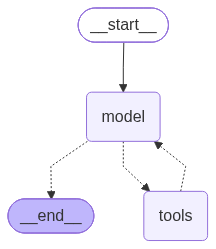

In [87]:
from IPython.display import Image, display

graph = resilient_agent.get_graph()

display(Image(graph.draw_mermaid_png()))

In [88]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Summarize my chat? ',
            additional_kwargs={},
            response_metadata={},
            id='1bf452b0-05be-41eb-b16b-c63bbb7d96e7'
        ),
        AIMessage(
            content='There is nothing to summarize yet. What would you like to talk about?',
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 16,
                    'prompt_tokens': 567,
                    'total_tokens': 583,
                    'completion_time': 0.028868988,
                    'completion_tokens_details': None,
                    'prompt_time': 0.045882514,
                    'prompt_tokens_details': None,
                    'queue_time': 0.062701195,
                    'total_time': 0.074751502
                },
                'model_name': 'llama-3.1-8b-instant',
                'system_fingerprint': 'fp_4387d3edbb',
                'service_tier': 'on_demand',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--019fe21d-fd23-7f61-865e-17b5ed82239b-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 567, 'output_tokens': 16, 'total_tokens': 583}
        )
    ]
}

# Tool Call Limit

In [90]:
tool_limited_agent = create_agent(
    model=llm,
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2),  # tighter, one tool, whole conversation
    ],
)